# 04 · Producción regional — Departamento Maracó, La Pampa

Análisis de los datos históricos de producción agrícola del Departamento Maracó  
provenientes de MAGyP (SIIA) y cruce con los scores agronómicos de la finca Trebolares.

**Cultivos:** Maíz · Trigo · Soja de primera · Soja de segunda  
**Fuente:** datos.magyp.gob.ar — Estimaciones Agrícolas por departamento

## 0 · Setup

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
PROC = ROOT / 'data' / 'trebolares' / 'processed'

COLORS = {
    'Maíz':             '#E8A838',
    'Trigo':            '#8B6914',
    'Soja de primera':  '#3A7D44',
    'Soja de segunda':  '#83C27B',
}
SCENARIO_MAP = {
    'Maíz':            ['maize_early', 'maize_late'],
    'Trigo':           ['wheat'],
    'Soja de primera': ['soy_first'],
    'Soja de segunda': ['soy_second'],
}
CLASS_COLORS = {'Favorable': '#3A7D44', 'Intermedia': '#E8A838', 'Restrictiva': '#C0392B'}

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 130})
print('ROOT:', ROOT)

ROOT: C:\Users\Usuario\OneDrive\appsheet\Antigravity\Proyecto ClimaData


## 1 · Carga de datos

In [2]:
# Producción regional
prod = pd.read_parquet(PROC / 'produccion_regional.parquet')
prod['rendimiento_kgxha'] = pd.to_numeric(prod['rendimiento_kgxha'], errors='coerce')

with open(PROC / 'produccion_meta.json') as f:
    meta = json.load(f)

# Scores agronómicos
SCENARIOS = ['maize_early', 'maize_late', 'wheat', 'soy_first', 'soy_second']
agro = {sc: pd.read_parquet(PROC / f'agro_{sc}_campaign_summary.parquet') for sc in SCENARIOS}

print(f'Producción regional: {len(prod)} filas')
for cultivo, grp in prod.groupby('cultivo'):
    rend = grp['rendimiento_kgxha'].dropna()
    s = meta['crops'].get([k for k,v in {'maize':'Maíz','wheat':'Trigo','soy_first':'Soja de primera','soy_second':'Soja de segunda'}.items() if v==cultivo][0] if cultivo != 'Maíz' else 'maize', {})
    print(f'  {cultivo:20s}  {len(grp):3d} campañas  rend. medio {rend.mean():.0f} kg/ha  CV {rend.std()/rend.mean()*100:.0f}%')

Producción regional: 240 filas
  Maíz                  102 campañas  rend. medio 2902 kg/ha  CV 95%
  Soja de primera        20 campañas  rend. medio 2760 kg/ha  CV 28%
  Soja de segunda        20 campañas  rend. medio 2007 kg/ha  CV 39%
  Trigo                  98 campañas  rend. medio 1404 kg/ha  CV 60%


## 2 · Serie histórica de rendimientos por cultivo

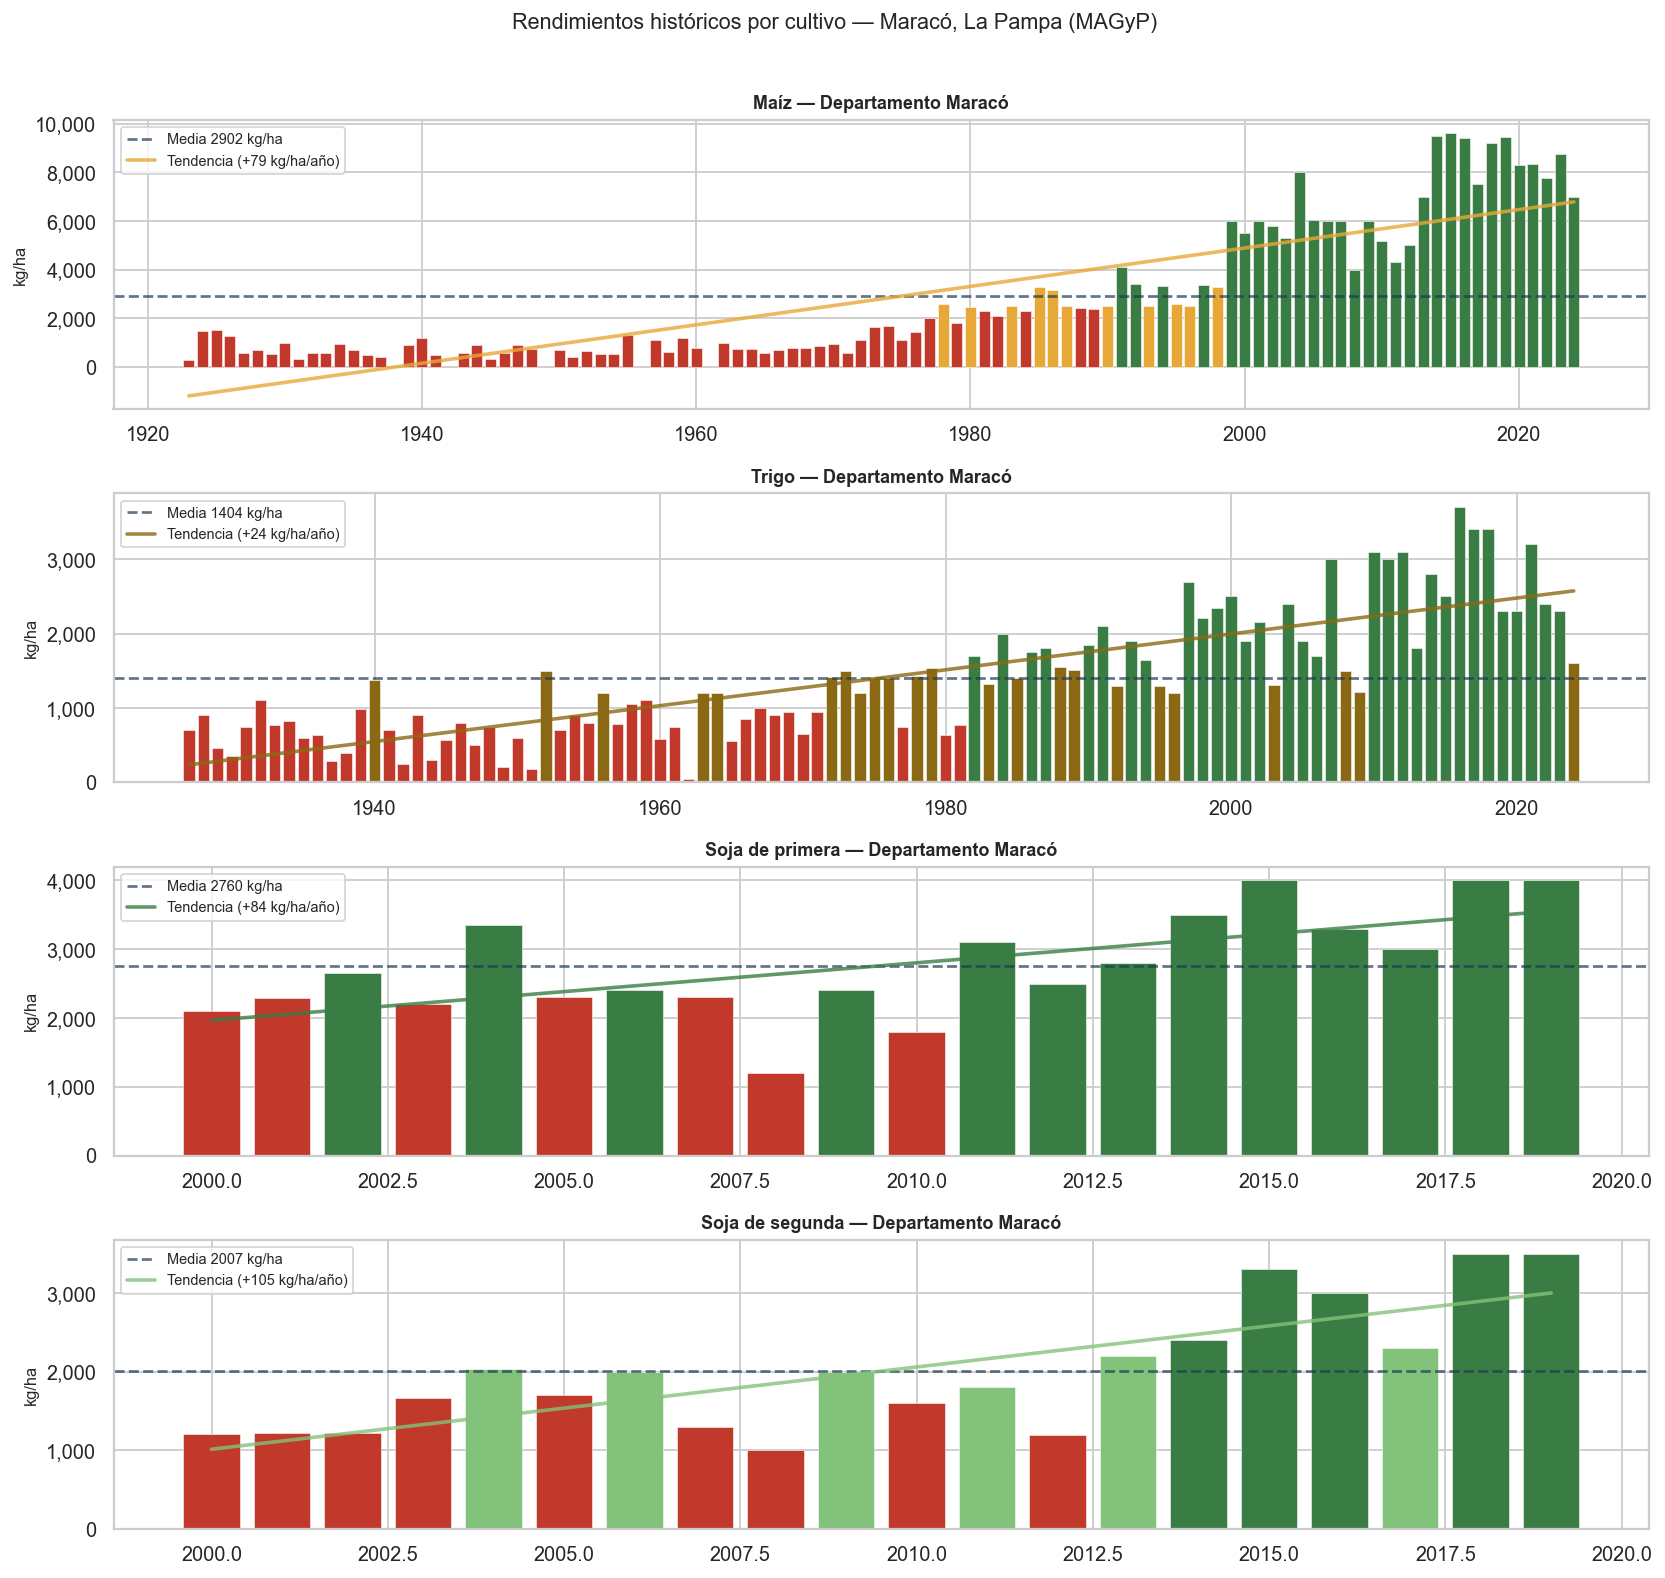

In [3]:
cultivos = prod['cultivo'].unique()
fig, axes = plt.subplots(len(cultivos), 1, figsize=(13, 12), sharex=False)

for ax, cultivo in zip(axes, cultivos):
    sub = prod[prod['cultivo'] == cultivo].dropna(subset=['rendimiento_kgxha'])
    color = COLORS.get(cultivo, '#607E93')
    mean_val = sub['rendimiento_kgxha'].mean()

    bar_colors = [
        '#3A7D44' if v >= mean_val * 1.15 else ('#C0392B' if v <= mean_val * 0.85 else color)
        for v in sub['rendimiento_kgxha']
    ]
    ax.bar(sub['anio'], sub['rendimiento_kgxha'], color=bar_colors,
           edgecolor='white', linewidth=0.3, width=0.8)
    ax.axhline(mean_val, color='#1E3953', lw=1.5, ls='--', alpha=0.7,
               label=f'Media {mean_val:.0f} kg/ha')

    # Tendencia
    z = np.polyfit(sub['anio'], sub['rendimiento_kgxha'], 1)
    ax.plot(sub['anio'], np.poly1d(z)(sub['anio']),
            color=color, lw=2, alpha=0.8, label=f'Tendencia ({z[0]:+.0f} kg/ha/año)')

    ax.set_ylabel('kg/ha', fontsize=9)
    ax.set_title(f'{cultivo} — Departamento Maracó', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Rendimientos históricos por cultivo — Maracó, La Pampa (MAGyP)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3 · Superficie sembrada y cosechada — evolución

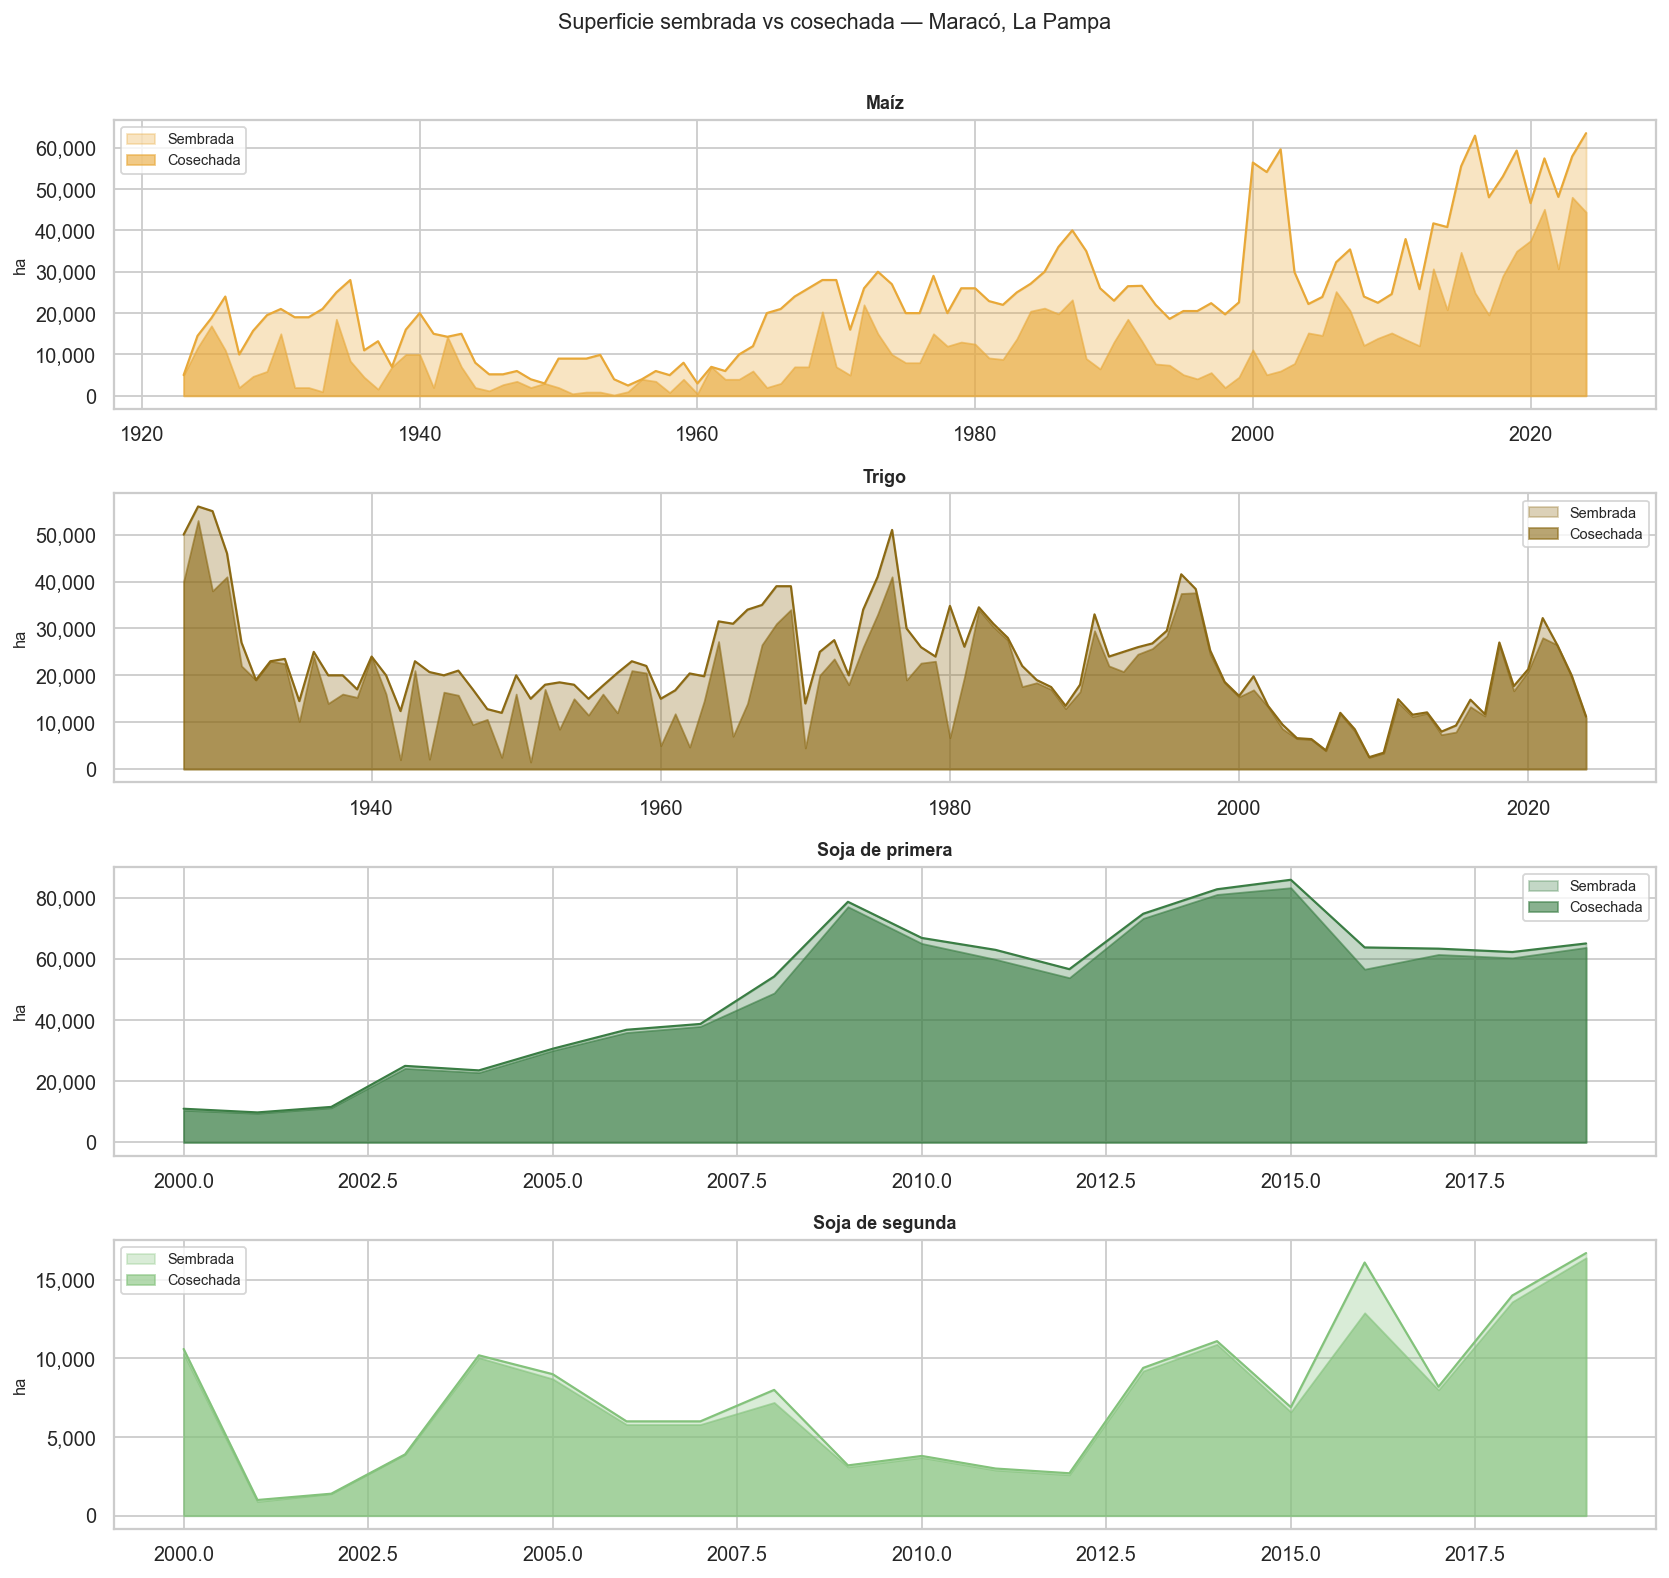

In [4]:
fig, axes = plt.subplots(len(cultivos), 1, figsize=(13, 12), sharex=False)

for ax, cultivo in zip(axes, cultivos):
    sub = prod[prod['cultivo'] == cultivo].dropna(subset=['superficie_sembrada_ha'])
    color = COLORS.get(cultivo, '#607E93')

    ax.fill_between(sub['anio'], sub['superficie_sembrada_ha'],
                    alpha=0.3, color=color, label='Sembrada')
    ax.fill_between(sub['anio'], sub['superficie_cosechada_ha'].fillna(sub['superficie_sembrada_ha']),
                    alpha=0.6, color=color, label='Cosechada')
    ax.plot(sub['anio'], sub['superficie_sembrada_ha'], color=color, lw=1.2)

    ax.set_ylabel('ha', fontsize=9)
    ax.set_title(f'{cultivo}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Superficie sembrada vs cosechada — Maracó, La Pampa', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4 · Estadísticas descriptivas por cultivo (período moderno 2001–2024)

In [5]:
modern = prod[prod['anio'] >= 2001].copy()

rows = []
for cultivo, grp in modern.groupby('cultivo'):
    rend = grp['rendimiento_kgxha'].dropna()
    rows.append({
        'Cultivo':        cultivo,
        'Campañas':       len(rend),
        'Rend. medio (kg/ha)': round(rend.mean(), 0),
        'Rend. máx (kg/ha)':  round(rend.max(), 0),
        'Rend. mín (kg/ha)':  round(rend.min(), 0),
        'CV (%)':         round(rend.std() / rend.mean() * 100, 1),
        'Mejor año':      int(grp.loc[grp['rendimiento_kgxha'].idxmax(), 'anio']),
        'Peor año':       int(grp.loc[grp['rendimiento_kgxha'].idxmin(), 'anio']),
    })

desc_df = pd.DataFrame(rows).set_index('Cultivo')
desc_df.style.background_gradient(subset=['Rend. medio (kg/ha)'], cmap='YlGn') \
             .format({'CV (%)': '{:.1f}%', 'Rend. medio (kg/ha)': '{:.0f}',
                      'Rend. máx (kg/ha)': '{:.0f}', 'Rend. mín (kg/ha)': '{:.0f}'})

,Campañas,Rend. medio (kg/ha),Rend. máx (kg/ha),Rend. mín (kg/ha),CV (%),Mejor año,Peor año
Cultivo,,,,,,,
Maíz,24,7059,9600,4000,24.8%,2015,2008
Soja de primera,19,2795,4000,1200,27.5%,2015,2008
Soja de segunda,19,2049,3500,1000,38.5%,2018,2008
Trigo,24,2415,3700,1216,29.5%,2016,2009


## 5 · Score agronómico vs rendimiento real — cruce directo

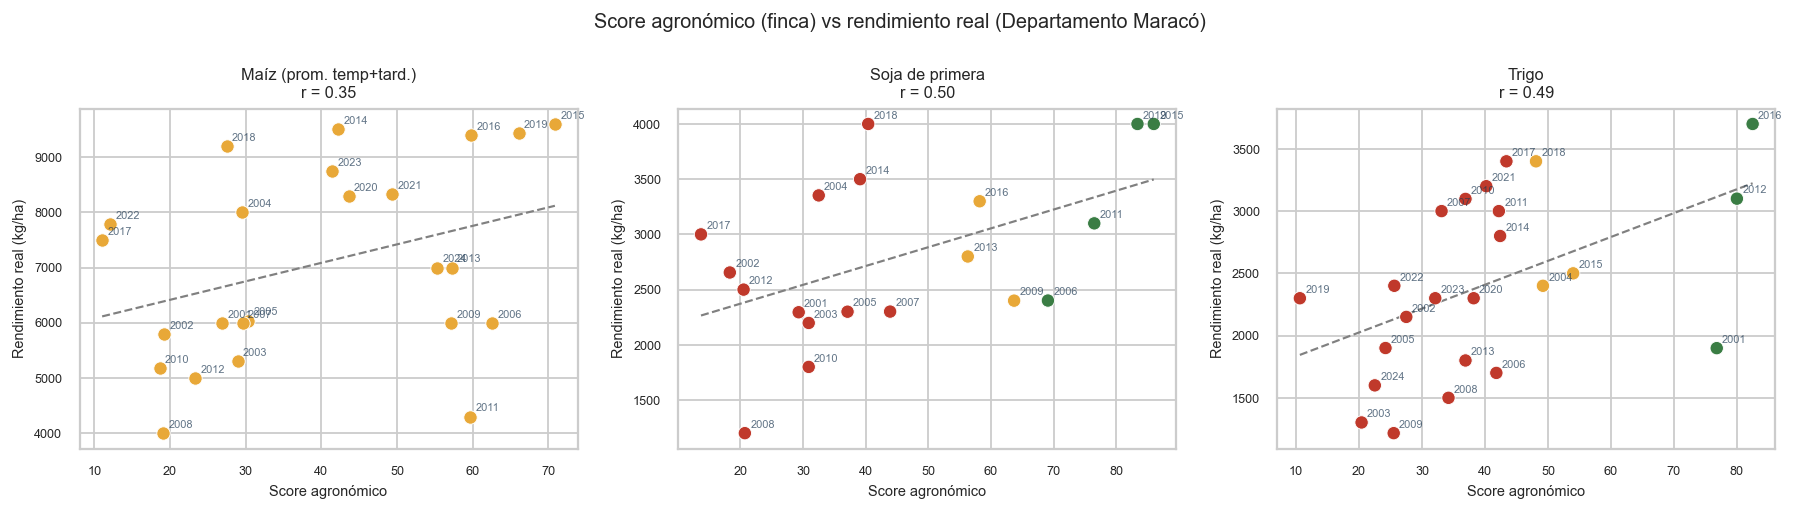

In [6]:
# Maíz: promedio maize_early + maize_late como score representativo
maize_score = (
    pd.concat([agro['maize_early'], agro['maize_late']])
    .groupby('campaign_start_year')['agro_score'].mean()
    .reset_index()
    .rename(columns={'agro_score': 'score_medio'})
)

maiz_prod = prod[(prod['cultivo'] == 'Maíz') & (prod['anio'] >= 2001)][['anio','rendimiento_kgxha']].dropna()
maiz_merged = maiz_prod.merge(maize_score, left_on='anio', right_on='campaign_start_year')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ('Maíz',            maiz_merged, 'score_medio',      '#E8A838'),
]

# Add soja and trigo
soja_score = agro['soy_first'][['campaign_start_year','agro_score','campaign_class']].rename(columns={'agro_score':'score_medio'})
soja_prod  = prod[(prod['cultivo']=='Soja de primera') & (prod['anio']>=2001)][['anio','rendimiento_kgxha']].dropna()
soja_merged = soja_prod.merge(soja_score, left_on='anio', right_on='campaign_start_year')

trigo_score = agro['wheat'][['campaign_start_year','agro_score','campaign_class']].rename(columns={'agro_score':'score_medio'})
trigo_prod  = prod[(prod['cultivo']=='Trigo') & (prod['anio']>=2001)][['anio','rendimiento_kgxha']].dropna()
trigo_merged = trigo_prod.merge(trigo_score, left_on='anio', right_on='campaign_start_year')

datasets = [
    ('Maíz (prom. temp+tard.)', maiz_merged, '#E8A838'),
    ('Soja de primera',         soja_merged, '#3A7D44'),
    ('Trigo',                   trigo_merged, '#8B6914'),
]

for ax, (title, df, color) in zip(axes, datasets):
    if df.empty:
        ax.set_visible(False)
        continue

    # Color by class if available
    if 'campaign_class' in df.columns:
        c = df['campaign_class'].map(CLASS_COLORS).fillna(color)
    else:
        c = color

    ax.scatter(df['score_medio'], df['rendimiento_kgxha'],
               c=c, s=55, edgecolors='white', linewidths=0.5, zorder=3)

    # Anotar año
    for _, row in df.iterrows():
        ax.annotate(str(int(row['anio'])),
                    (row['score_medio'], row['rendimiento_kgxha']),
                    textcoords='offset points', xytext=(3, 3),
                    fontsize=6, color='#1E3953', alpha=0.7)

    # Tendencia
    valid = df[['score_medio','rendimiento_kgxha']].dropna()
    if len(valid) > 3:
        m, b = np.polyfit(valid['score_medio'], valid['rendimiento_kgxha'], 1)
        x_line = np.linspace(valid['score_medio'].min(), valid['score_medio'].max(), 100)
        ax.plot(x_line, m*x_line + b, color='gray', lw=1.2, ls='--')
        r = valid.corr().iloc[0,1]
        ax.set_title(f'{title}\nr = {r:.2f}', fontsize=9)
    else:
        ax.set_title(title, fontsize=9)

    ax.set_xlabel('Score agronómico', fontsize=8)
    ax.set_ylabel('Rendimiento real (kg/ha)', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Score agronómico (finca) vs rendimiento real (Departamento Maracó)', fontsize=11)
plt.tight_layout()
plt.show()

## 6 · Rendimiento real por año — comparado con clase agronómica de la finca

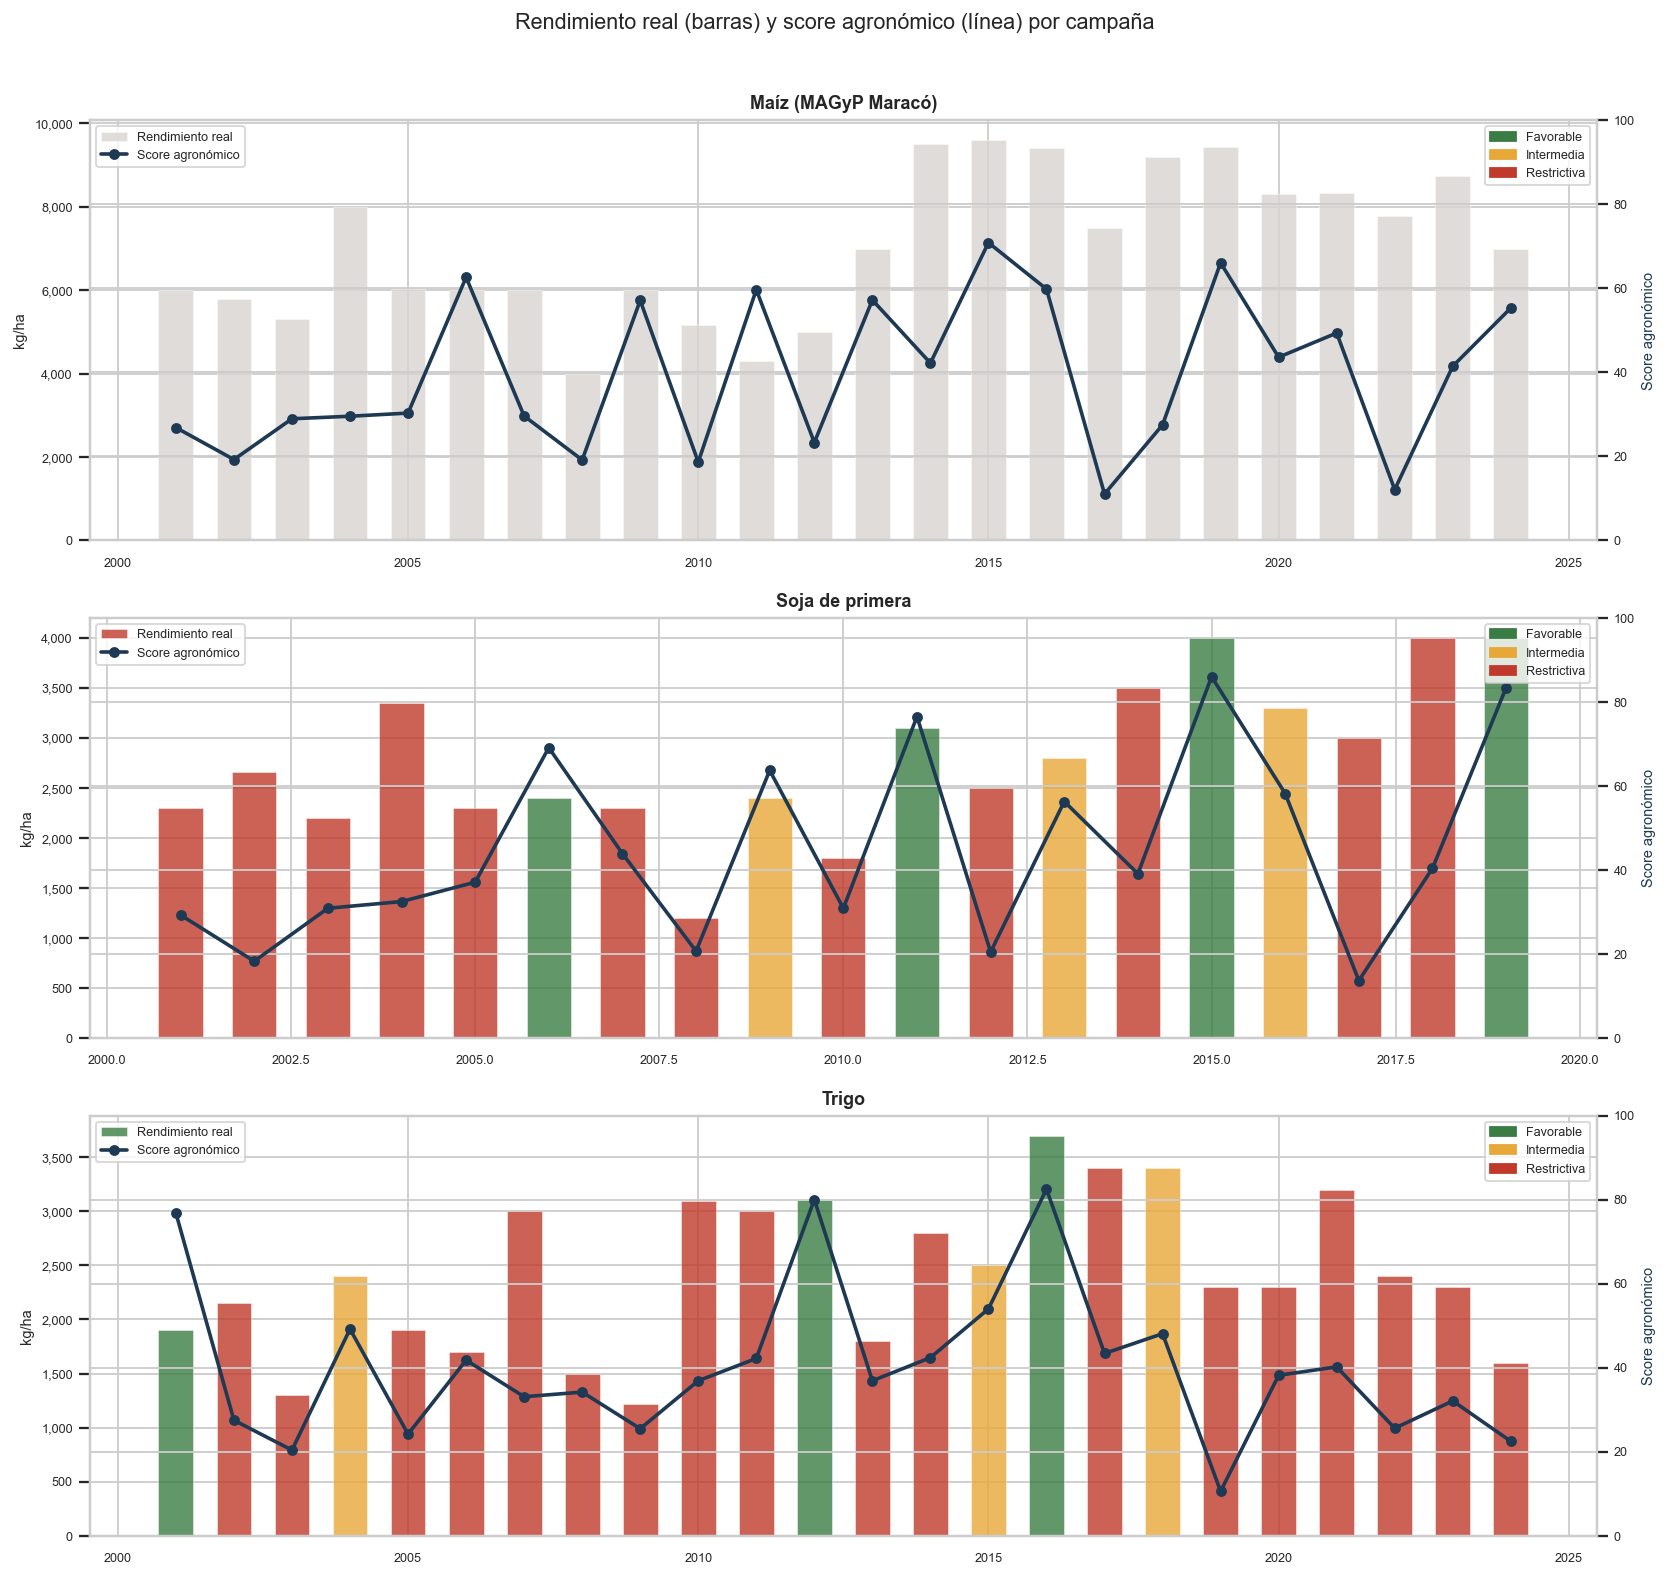

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)

pairs = [
    ('Maíz (MAGyP Maracó)',    maiz_merged,  '#E8A838'),
    ('Soja de primera',        soja_merged,  '#3A7D44'),
    ('Trigo',                  trigo_merged, '#8B6914'),
]

for ax, (title, df, color) in zip(axes, pairs):
    if df.empty:
        continue

    ax2 = ax.twinx()

    # Rendimiento real (barras)
    bar_colors = df.get('campaign_class', pd.Series([''] * len(df))).map(CLASS_COLORS).fillna('#D8D4D0')
    ax.bar(df['anio'], df['rendimiento_kgxha'], color=bar_colors,
           edgecolor='white', linewidth=0.3, width=0.6, alpha=0.8, label='Rendimiento real')

    # Score (línea, eje derecho)
    ax2.plot(df['anio'], df['score_medio'], color='#1E3953',
             lw=2, marker='o', markersize=5, label='Score agronómico')
    ax2.set_ylabel('Score agronómico', fontsize=8, color='#1E3953')
    ax2.set_ylim(0, 100)
    ax2.tick_params(labelsize=7)

    ax.set_ylabel('kg/ha', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')

    # Color de fondo por clase
    from matplotlib.patches import Patch
    legend_els = [Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
    ax2.legend(handles=legend_els, fontsize=7, loc='upper right')

fig.suptitle('Rendimiento real (barras) y score agronómico (línea) por campaña', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7 · Rendimiento medio por clase agronómica — ¿el score discrimina?

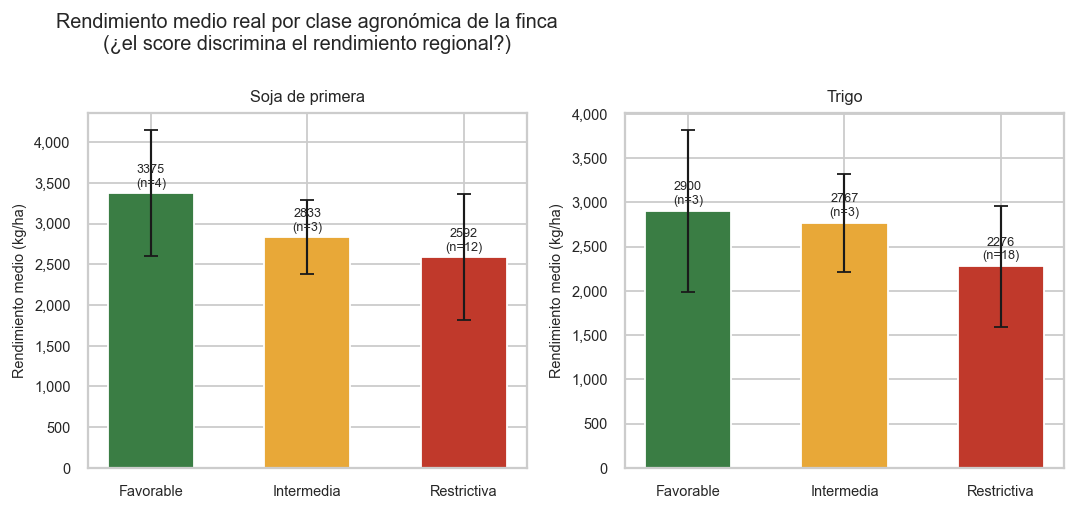

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (title, df, color) in zip(axes, pairs):
    if df.empty or 'campaign_class' not in df.columns:
        ax.set_visible(False)
        continue

    grp = df.groupby('campaign_class')['rendimiento_kgxha'].agg(['mean','std','count'])
    order = ['Favorable','Intermedia','Restrictiva']
    grp = grp.reindex([c for c in order if c in grp.index])

    bars = ax.bar(grp.index, grp['mean'],
                  color=[CLASS_COLORS[c] for c in grp.index],
                  edgecolor='white', width=0.55,
                  yerr=grp['std'], capsize=4, error_kw={'linewidth':1.2})

    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + grp['std'].max()*0.05,
                f'{row["mean"]:.0f}\n(n={int(row["count"])})',
                ha='center', va='bottom', fontsize=7)

    ax.set_title(title, fontsize=9)
    ax.set_ylabel('Rendimiento medio (kg/ha)', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Rendimiento medio real por clase agronómica de la finca\n(¿el score discrimina el rendimiento regional?)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 8 · Heatmap año × cultivo — rendimiento real normalizado

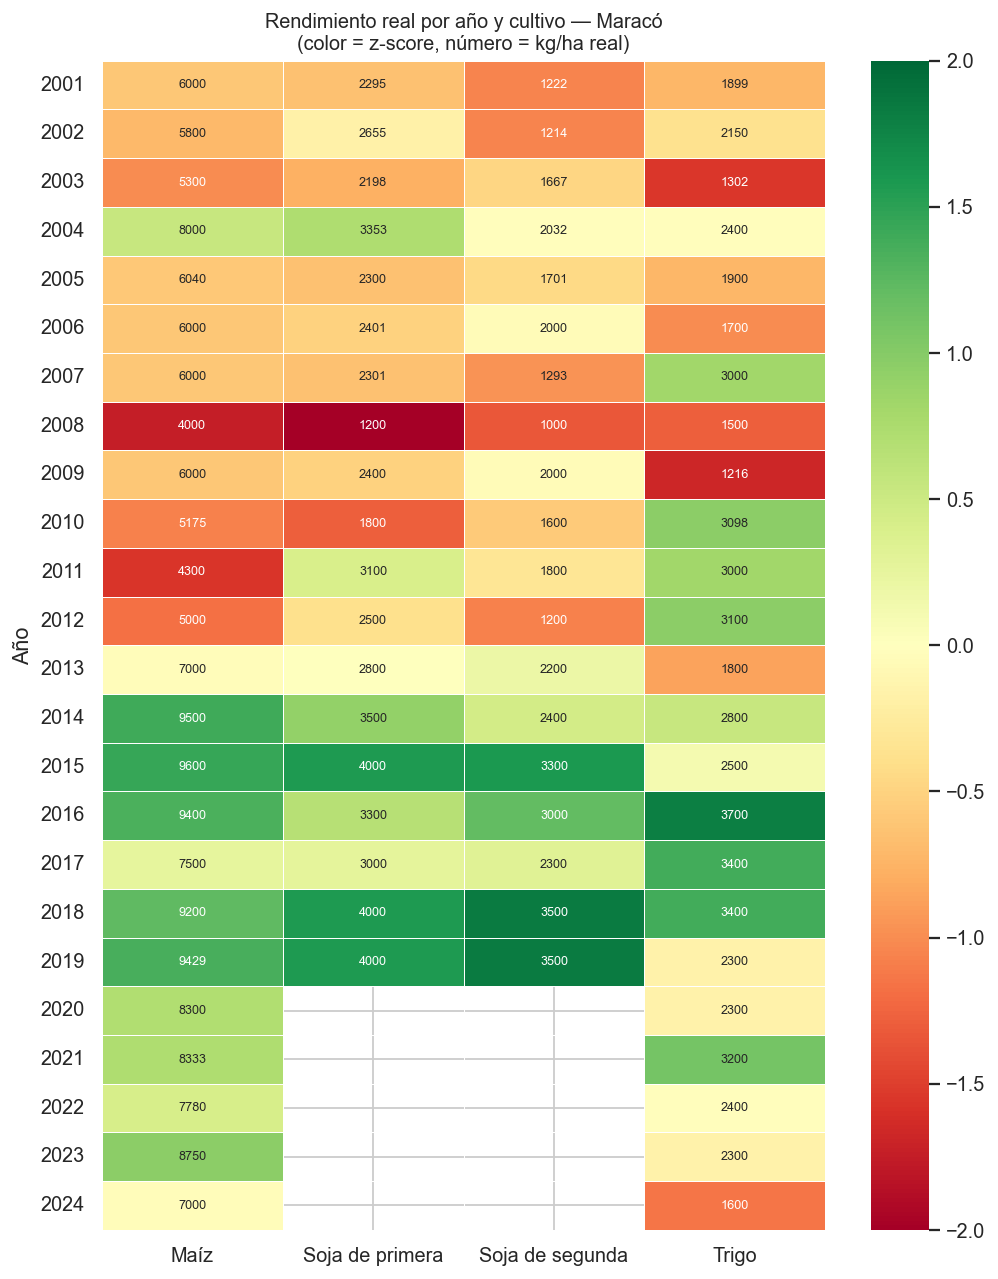

In [9]:
modern = prod[prod['anio'] >= 2001].copy()

pivot = modern.pivot_table(index='anio', columns='cultivo', values='rendimiento_kgxha')
# Normalizar por columna (z-score) para comparar entre cultivos
pivot_z = (pivot - pivot.mean()) / pivot.std()

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    pivot_z, annot=pivot.round(0), fmt='.0f',
    cmap='RdYlGn', center=0, vmin=-2, vmax=2,
    linewidths=0.3, linecolor='white',
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Rendimiento real por año y cultivo — Maracó\n(color = z-score, número = kg/ha real)', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('Año')
plt.tight_layout()
plt.show()

## 9 · Tendencia de largo plazo — cambio tecnológico

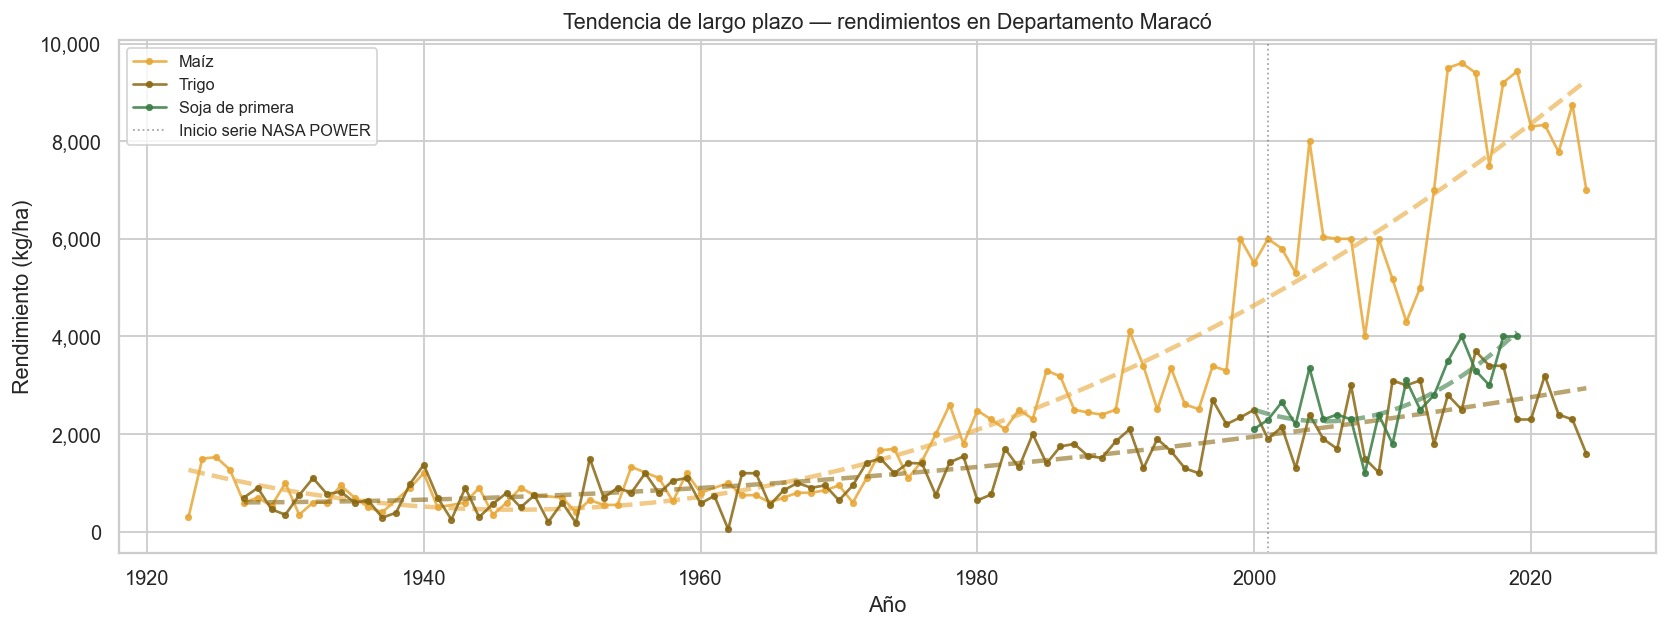

Rendimiento medio antes y después del año 2001:
  Maíz                  pre-2001: 1535 kg/ha  |  2001+: 7059 kg/ha  |  cambio: +360%
  Trigo                 pre-2001: 1077 kg/ha  |  2001+: 2415 kg/ha  |  cambio: +124%


In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

for cultivo in ['Maíz', 'Trigo', 'Soja de primera']:
    sub = prod[prod['cultivo'] == cultivo].dropna(subset=['rendimiento_kgxha'])
    color = COLORS.get(cultivo, '#607E93')

    ax.plot(sub['anio'], sub['rendimiento_kgxha'], color=color, lw=1.5,
            marker='o', markersize=3, label=cultivo, alpha=0.85)

    # Tendencia polinómica grado 2
    z = np.polyfit(sub['anio'], sub['rendimiento_kgxha'], 2)
    x_line = np.linspace(sub['anio'].min(), sub['anio'].max(), 200)
    ax.plot(x_line, np.poly1d(z)(x_line), color=color, lw=2.5, ls='--', alpha=0.6)

ax.axvline(2001, color='gray', lw=1, ls=':', alpha=0.7, label='Inicio serie NASA POWER')
ax.set_xlabel('Año')
ax.set_ylabel('Rendimiento (kg/ha)')
ax.set_title('Tendencia de largo plazo — rendimientos en Departamento Maracó')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

# Comparar media pre/post 2001
print('Rendimiento medio antes y después del año 2001:')
for cultivo in ['Maíz','Trigo']:
    sub = prod[prod['cultivo']==cultivo].dropna(subset=['rendimiento_kgxha'])
    pre  = sub[sub['anio'] < 2001]['rendimiento_kgxha'].mean()
    post = sub[sub['anio'] >= 2001]['rendimiento_kgxha'].mean()
    print(f'  {cultivo:20s}  pre-2001: {pre:.0f} kg/ha  |  2001+: {post:.0f} kg/ha  |  cambio: {(post-pre)/pre*100:+.0f}%')

## 10 · Resumen interpretativo

In [11]:
print('RESUMEN — Producción regional vs score agronómico (Maracó, La Pampa)')
print('='*65)
print()

for title, df, _ in pairs:
    if df.empty or 'score_medio' not in df.columns:
        continue
    valid = df[['score_medio','rendimiento_kgxha']].dropna()
    r = valid.corr().iloc[0,1] if len(valid) > 3 else float('nan')
    rend_mean = valid['rendimiento_kgxha'].mean()
    rend_cv   = valid['rendimiento_kgxha'].std() / rend_mean * 100
    print(f'  {title}')
    print(f'    Correlación score vs rendimiento real: r = {r:.2f}')
    print(f'    Rendimiento medio 2001+: {rend_mean:.0f} kg/ha  |  CV: {rend_cv:.0f}%')
    if abs(r) >= 0.5:
        print(f'    → El score agronómico tiene poder predictivo MODERADO-ALTO sobre el rendimiento regional')
    elif abs(r) >= 0.3:
        print(f'    → El score agronómico tiene correlación DÉBIL con el rendimiento regional')
    else:
        print(f'    → Sin correlación clara: el rendimiento regional tiene otros determinantes (tecnología, manejo)')
    print()

RESUMEN — Producción regional vs score agronómico (Maracó, La Pampa)

  Maíz (MAGyP Maracó)
    Correlación score vs rendimiento real: r = 0.35
    Rendimiento medio 2001+: 7059 kg/ha  |  CV: 25%
    → El score agronómico tiene correlación DÉBIL con el rendimiento regional

  Soja de primera
    Correlación score vs rendimiento real: r = 0.50
    Rendimiento medio 2001+: 2795 kg/ha  |  CV: 27%
    → El score agronómico tiene poder predictivo MODERADO-ALTO sobre el rendimiento regional

  Trigo
    Correlación score vs rendimiento real: r = 0.49
    Rendimiento medio 2001+: 2415 kg/ha  |  CV: 30%
    → El score agronómico tiene correlación DÉBIL con el rendimiento regional

